In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

base = Path.cwd()

file_path_train = base.parent.parent /"Data"/"Continuous"/"nyc taxi"/"train.csv"
file_path_test = base.parent.parent /"Data"/"Continuous"/"nyc taxi"/"test.csv"

print(file_path_train)
print(file_path_train.exists())

df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

df_train.head()

c:\Users\takun\OneDrive\Desktop\Stats\Stats\Data\Continuous\nyc taxi\train.csv
True


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [2]:
for col in df_train.columns:
    print(col, df_train[col].dtype, df_train[col].isnull().sum(), df_train[col].nunique())

id object 0 1458644
vendor_id int64 0 2
pickup_datetime object 0 1380222
dropoff_datetime object 0 1380377
passenger_count int64 0 10
pickup_longitude float64 0 23047
pickup_latitude float64 0 45245
dropoff_longitude float64 0 33821
dropoff_latitude float64 0 62519
store_and_fwd_flag object 0 2
trip_duration int64 0 7417


In [3]:
def drop_leakage(df):
    df = df.drop(columns=['id','dropoff_datetime'])
    return df

In [4]:
df_train = drop_leakage(df_train)
df_train.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
def convert_to_cat(df,cols):
    for col in cols:
        df[col] = df[col].astype('category')
    return df

In [6]:
cols = ['vendor_id','passenger_count']
convert_to_cat(df_train, cols)

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373


In [7]:
for col in df_train.columns:
    print(col, df_train[col].dtype, df_train[col].isnull().sum(), df_train[col].nunique())

vendor_id category 0 2
pickup_datetime object 0 1380222
passenger_count category 0 10
pickup_longitude float64 0 23047
pickup_latitude float64 0 45245
dropoff_longitude float64 0 33821
dropoff_latitude float64 0 62519
store_and_fwd_flag object 0 2
trip_duration int64 0 7417


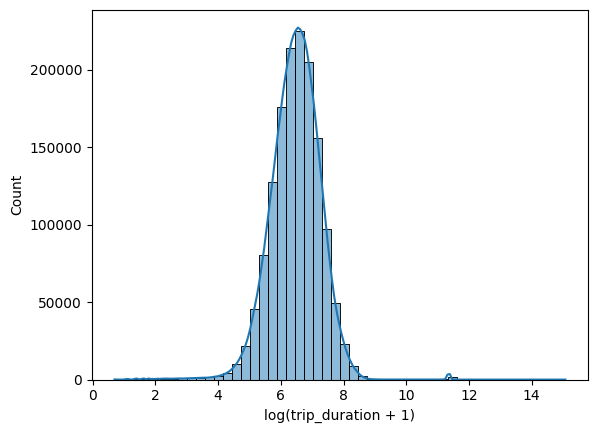

In [8]:
sns.histplot(np.log1p(df_train['trip_duration']), bins=50, kde=True)
plt.xlabel('log(trip_duration + 1)')
plt.show()

In [9]:
df_train["log_trip_duration"] = np.log1p(df_train['trip_duration'])


In [10]:
def haversine_distance(lat1, lon1, lat2,lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1,lat2,lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1
    a = np.sin(dlat/2)**2 +np.cos(lat1) *np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def manhattan_distance(lat1, lon1, lat2, lon2):

    a = haversine_distance(lat1, lon1, lat2, lon1)
    
    b = haversine_distance(lat1, lon1, lat1, lon2)
    return a + b

def bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return np.degrees(np.arctan2(x, y))

def feature_engineering(df, lat1, lon1,lat2,lon2):
    df["haversine_distance"] = haversine_distance(df["pickup_latitude"],
                                                    df["pickup_longitude"],
                                                    df["dropoff_latitude"],
                                                    df["dropoff_longitude"])
    df["manhattan_distance"] = manhattan_distance(df["pickup_latitude"],
                                                    df["pickup_longitude"],
                                                    df["dropoff_latitude"],
                                                    df["dropoff_longitude"])
    df["bearing"] = bearing(df["pickup_latitude"],
                                                    df["pickup_longitude"],
                                                    df["dropoff_latitude"],
                                                    df["dropoff_longitude"])
    return df
        

In [11]:
feature_engineering(df_train,
                    df_train["pickup_latitude"],
                    df_train["pickup_longitude"],
                    df_train["dropoff_latitude"],
                    df_train["dropoff_longitude"])

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,haversine_distance,manhattan_distance,bearing
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,6.122493,1.498521,1.735433,99.970196
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,6.498282,1.805507,2.430506,-117.153768
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,7.661527,6.385098,8.203575,-159.680165
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,6.063785,1.485498,1.661331,-172.737700
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,6.077642,1.188588,1.199457,179.473585
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,6.658011,1.225080,1.665895,-119.059338
1458640,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,6.486161,6.049836,8.058580,25.342196
1458641,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6.639876,7.824606,10.645646,-150.788492
1458642,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,5.924256,1.092564,1.521850,35.033294


In [12]:
def drop_latlong(df):
    cols = ["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"]
    df.drop(columns=cols, inplace=True)
    return df
    
    
def clean_trip_outliers(df, target_col="trip_duration",
                         lat1="pickup_latitude", lon1="pickup_longitude",
                         lat2="dropoff_latitude", lon2="dropoff_longitude",
                         min_speed_kmh=1.0, max_speed_kmh=140.0,
                         min_duration_seconds=30,
                         iqr_multiplier=3.0,
                         min_distance_km=0.05,
                         std_multiplier=2.0):
    """Remove trips that are implausible on physical grounds rather than a
    fixed duration cutoff. Must be called BEFORE drop_latlong, since it
    needs the raw lat/long columns to compute distance and implied speed.
 
    Flags dropped for:
    - near-zero distance trips lasting a long time, or near-zero duration
      trips covering real distance (both usually GPS/meter glitches)
    - implied average speed outside [min_speed_kmh, max_speed_kmh] -- e.g.
      a trip "covering" 2km in 5 seconds (>1000 km/h) or 500m over 2 hours
      (<1 km/h) is not a real taxi ride, it's a bad timestamp or bad GPS fix
    - log_trip_duration values beyond iqr_multiplier * IQR from the
      1st/3rd quartiles -- catches remaining statistical outliers (e.g. the
      24h-cluster / multi-day artifacts) without a hardcoded duration cap
    - trip_duration more than std_multiplier standard deviations ABOVE the
      mean (upper side only -- unusually short trips are left to the other
      checks, since a short-but-real trip isn't a data problem)
    """
    n_before = len(df)
 
    dist_km = haversine_distance(df[lat1], df[lon1], df[lat2], df[lon2])
    duration_hr = df[target_col] / 3600.0
    # avoid divide-by-zero for zero-duration rows
    implied_speed_kmh = dist_km / duration_hr.replace(0, np.nan)
 
    speed_mask = implied_speed_kmh.between(min_speed_kmh, max_speed_kmh)
    # rows with essentially no movement AND no meaningful duration are
    # ambiguous (0/0) rather than physically implausible -- drop separately
    degenerate_mask = (dist_km < min_distance_km) & (df[target_col] < min_duration_seconds)
 
    log_dur = np.log1p(df[target_col])
    q1, q3 = log_dur.quantile(0.25), log_dur.quantile(0.75)
    iqr = q3 - q1
    iqr_mask = log_dur.between(q1 - iqr_multiplier * iqr, q3 + iqr_multiplier * iqr)
 
    mean_dur, std_dur = df[target_col].mean(), df[target_col].std()
    upper_std_bound = mean_dur + std_multiplier * std_dur
    std_mask = df[target_col] <= upper_std_bound
 
    keep_mask = speed_mask.fillna(False) & iqr_mask & std_mask & ~degenerate_mask
 
    dropped_summary = {
        "n_before": n_before,
        "n_after": int(keep_mask.sum()),
        "n_dropped_speed": int((~speed_mask.fillna(False)).sum()),
        "n_dropped_iqr": int((~iqr_mask).sum()),
        "n_dropped_std": int((~std_mask).sum()),
        "n_dropped_degenerate": int(degenerate_mask.sum()),
        "n_dropped_total": n_before - int(keep_mask.sum()),
    }
    print(f"Dropped {dropped_summary['n_dropped_total']} / {n_before} rows "
          f"({dropped_summary['n_dropped_total'] / n_before:.4%}): "
          f"{dropped_summary['n_dropped_speed']} speed outliers "
          f"(outside [{min_speed_kmh}, {max_speed_kmh}] km/h), "
          f"{dropped_summary['n_dropped_iqr']} log-duration IQR outliers, "
          f"{dropped_summary['n_dropped_std']} trips above mean + {std_multiplier} std "
          f"(> {upper_std_bound:.1f}s), "
          f"{dropped_summary['n_dropped_degenerate']} degenerate near-zero rows.")
 
    df.drop(df.index[~keep_mask], inplace=True)
    return df, dropped_summary

In [13]:
clean_trip_outliers(df_train)
drop_latlong(df_train)

Dropped 15428 / 1458644 rows (1.0577%): 13351 speed outliers (outside [1.0, 140.0] km/h), 5583 log-duration IQR outliers, 2104 trips above mean + 2.0 std (> 11434.4s), 3889 degenerate near-zero rows.


,vendor_id,pickup_datetime,passenger_count,store_and_fwd_flag,trip_duration,log_trip_duration,haversine_distance,manhattan_distance,bearing
0,2,2016-03-14 17:24:55,1,N,455,6.122493,1.498521,1.735433,99.970196
1,1,2016-06-12 00:43:35,1,N,663,6.498282,1.805507,2.430506,-117.153768
2,2,2016-01-19 11:35:24,1,N,2124,7.661527,6.385098,8.203575,-159.680165
3,2,2016-04-06 19:32:31,1,N,429,6.063785,1.485498,1.661331,-172.737700
4,2,2016-03-26 13:30:55,1,N,435,6.077642,1.188588,1.199457,179.473585
...,...,...,...,...,...,...,...,...,...
1458639,2,2016-04-08 13:31:04,4,N,778,6.658011,1.225080,1.665895,-119.059338
1458640,1,2016-01-10 07:35:15,1,N,655,6.486161,6.049836,8.058580,25.342196
1458641,2,2016-04-22 06:57:41,1,N,764,6.639876,7.824606,10.645646,-150.788492
1458642,1,2016-01-05 15:56:26,1,N,373,5.924256,1.092564,1.521850,35.033294


In [14]:
df_train.head()

,vendor_id,pickup_datetime,passenger_count,store_and_fwd_flag,trip_duration,log_trip_duration,haversine_distance,manhattan_distance,bearing
0,2,2016-03-14 17:24:55,1,N,455,6.122493,1.498521,1.735433,99.970196
1,1,2016-06-12 00:43:35,1,N,663,6.498282,1.805507,2.430506,-117.153768
2,2,2016-01-19 11:35:24,1,N,2124,7.661527,6.385098,8.203575,-159.680165
3,2,2016-04-06 19:32:31,1,N,429,6.063785,1.485498,1.661331,-172.737700
4,2,2016-03-26 13:30:55,1,N,435,6.077642,1.188588,1.199457,179.473585


In [15]:
def time_weather_features(df):
    df['datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.day_name()
    df.drop(columns="pickup_datetime",inplace=True)
    
    
    return df

In [16]:
time_weather_features(df_train)

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,log_trip_duration,haversine_distance,manhattan_distance,bearing,datetime,month,day,hour,weekday
0,2,1,N,455,6.122493,1.498521,1.735433,99.970196,2016-03-14 17:24:55,3,14,17,Monday
1,1,1,N,663,6.498282,1.805507,2.430506,-117.153768,2016-06-12 00:43:35,6,12,0,Sunday
2,2,1,N,2124,7.661527,6.385098,8.203575,-159.680165,2016-01-19 11:35:24,1,19,11,Tuesday
3,2,1,N,429,6.063785,1.485498,1.661331,-172.737700,2016-04-06 19:32:31,4,6,19,Wednesday
4,2,1,N,435,6.077642,1.188588,1.199457,179.473585,2016-03-26 13:30:55,3,26,13,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,4,N,778,6.658011,1.225080,1.665895,-119.059338,2016-04-08 13:31:04,4,8,13,Friday
1458640,1,1,N,655,6.486161,6.049836,8.058580,25.342196,2016-01-10 07:35:15,1,10,7,Sunday
1458641,2,1,N,764,6.639876,7.824606,10.645646,-150.788492,2016-04-22 06:57:41,4,22,6,Friday
1458642,1,1,N,373,5.924256,1.092564,1.521850,35.033294,2016-01-05 15:56:26,1,5,15,Tuesday


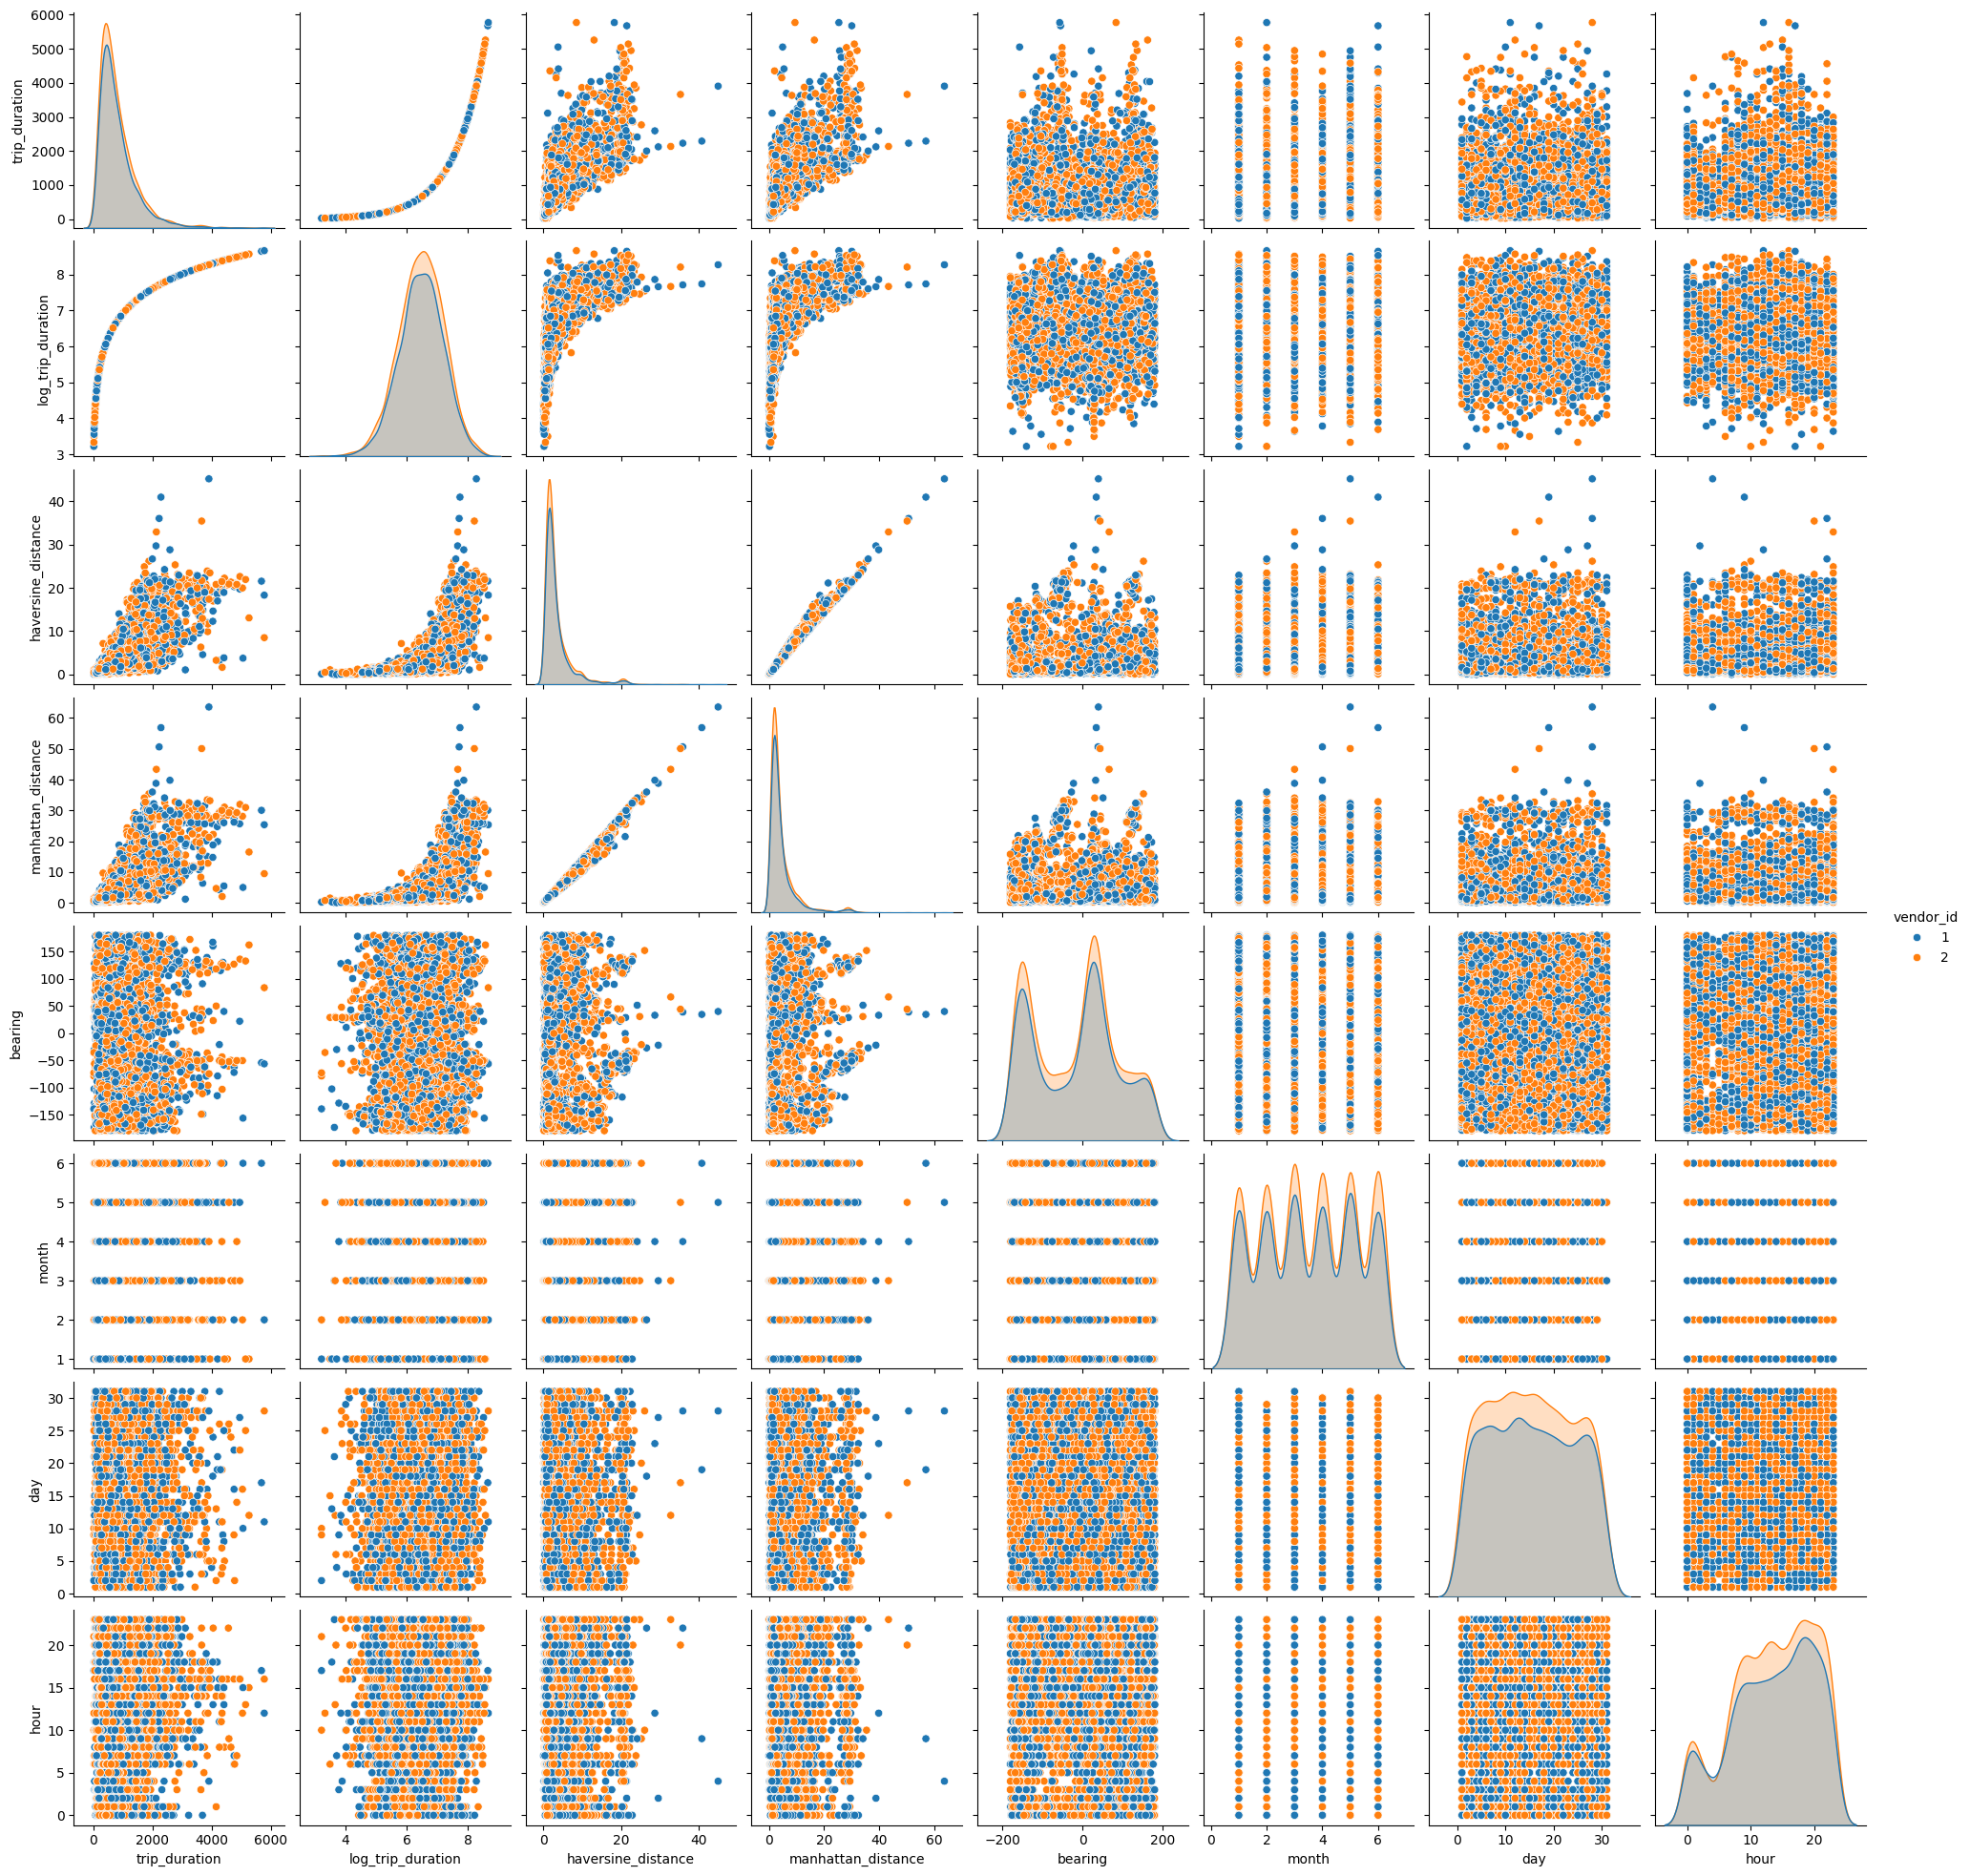

In [17]:
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

sns.pairplot(# Plots a random sample of 1,000 rows instead of the entire dataset
df_train.sample(10000)
, hue=cat_cols[0])
plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X, feature_names=None):
    if isinstance(X, pd.DataFrame):
        X_arr = X.values
    else:
        X_arr = np.asarray(X)
        if feature_names is None:
            feature_names = [f'x{i+1}' for i in range(X_arr.shape[1])]
            
    # drop columns that are constant/ all zero
    valid_cols=[]
    for i in range(X_arr.shape[1]):
        col = X_arr[:, i]
        if np.nanstd(col) == 0:
            print(f"Column {feature_names[i]} is constant and will be dropped")
        else:
            valid_cols.append(i)
        X_valid = X_arr[:, valid_cols]
        valid_names = [feature_names[i] for i in valid_cols]
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = valid_names
    vif_data["VIF"] = [
        variance_inflation_factor(X_valid, i) for i in range(X_valid.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42


def transform_data(df, target=None, test_size=0.2, random_state=RANDOM_STATE):

    df = df.copy()

    # Raw datetime64 columns match neither select_dtypes call below, so
    # ColumnTransformer's default remainder='drop' silently drops them with
    # no warning. Your engineered hour/dayofweek/month/etc columns are
    # already int64/float64 and pass through numeric_cols as normal --
    # this just clears out any leftover raw datetime column so nothing
    # goes missing silently.
    datetime_cols = df.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns.tolist()
    if datetime_cols:
        df.drop(columns=datetime_cols, inplace=True)

    # categorise into cat vs num
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    if target is not None:
        # normalise target to a list
        target_list = target if isinstance(target, list) else [target]
        target_cols = [t for t in target_list if t in numeric_cols]
        for t in target_cols:
            numeric_cols.remove(t)
        y = df[target_cols[0]] if len(target_cols) == 1 else df[target_cols]
    else:
        target_cols = []
        y = None

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # make sure target cols never get treated as categorical features
    categorical_cols = [c for c in categorical_cols if c not in target_cols]

    if y is not None:
        X_train_df, X_test_df, y_train, y_test = train_test_split(
            df, y, test_size=test_size, random_state=random_state
        )
    else:
        X_train_df, X_test_df = train_test_split(
            df, test_size=test_size, random_state=random_state
        )
        y_train, y_test = None, None

    # Numeric preprocessing
    numeric_transformer = Pipeline([
        ("scaler", StandardScaler())
    ])

    # Categorical preprocessing - keep sparse for memory efficiency
    categorical_transformer = Pipeline([
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True))
    ])

    transformer = [
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ]

    preprocessor = ColumnTransformer(transformers=transformer)

    X_train = preprocessor.fit_transform(X_train_df)
    X_test = preprocessor.transform(X_test_df)

    return X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df

In [20]:
X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df = transform_data(
    df_train, ["log_trip_duration", "trip_duration"]
)

feature_names = preprocessor.get_feature_names_out()
numeric_idx = [i for i, f in enumerate(feature_names) if f.startswith("numeric__")]
numeric_names = [feature_names[i] for i in numeric_idx]

X_train_numeric = X_train[:, numeric_idx]
if hasattr(X_train_numeric, "toarray"):
    X_train_numeric = X_train_numeric.toarray()

vif_results = calculate_vif(X_train_numeric, numeric_names)
print(vif_results)

                       feature        VIF
0  numeric__haversine_distance  83.893525
1  numeric__manhattan_distance  83.891791
2             numeric__bearing   1.000202


In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.gam.api import GLMGam, BSplines
from pygam import s, f, LinearGAM
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, root_mean_squared_error,
    median_absolute_error
)
from sklearn.model_selection import KFold
import gc
import itertools


def run_cv_and_fit(df, target="log_trip_duration", framework='pygam', fam_type='gaussian',
                    n_splits=5, random_state=RANDOM_STATE, sample_size=100_000,
                    n_splines=8, lam_grid=None, log_transform='log1p',
                    glmgam_df_smooth=6, glmgam_alpha=None,
                    reg_alpha_grid=None, reg_L1_wt_grid=None):

    X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df = transform_data(df, target)

    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    X_train = X_train.toarray().astype(np.float32) if hasattr(X_train, "toarray") else np.asarray(X_train, dtype=np.float32)
    X_test = X_test.toarray().astype(np.float32) if hasattr(X_test, "toarray") else np.asarray(X_test, dtype=np.float32)
    gc.collect()

    try:
        n_numeric = preprocessor.output_indices_["numeric"].stop - preprocessor.output_indices_["numeric"].start
    except Exception:
        n_numeric = X_train.shape[1]

    lam_grid = lam_grid if lam_grid is not None else np.logspace(-2, 2, 4)
    reg_alpha_grid = reg_alpha_grid if reg_alpha_grid is not None else [0.1, 3, 5]
    reg_L1_wt_grid = reg_L1_wt_grid if reg_L1_wt_grid is not None else [0.0, 0.25, 0.5, 0.75, 1.0]
    y_log_min, y_log_max = y_train.min(), y_train.max()

    def inv_transform(arr, clip):
        a = np.clip(arr, y_log_min, y_log_max) if clip else arr
        if log_transform == "log":
            return np.exp(a)
        elif log_transform == "log1p":
            return np.expm1(a)
        return None

    def subsample(X, y, n):
        if n is None or n >= X.shape[0]:
            return X, y, np.arange(X.shape[0])
        idx = np.random.RandomState(random_state).choice(X.shape[0], size=n, replace=False)
        return X[idx], y[idx], idx

    def clip_unseen_categories(X_val, X_fit, n_numeric):
     
        X_val = X_val.copy()
        for col in range(n_numeric, X_val.shape[1]):
            seen_vals, counts = np.unique(X_fit[:, col], return_counts=True)
            most_common = seen_vals[np.argmax(counts)]
            unseen_mask = ~np.isin(X_val[:, col], seen_vals)
            if unseen_mask.any():
                X_val[unseen_mask, col] = most_common
        return X_val

    def fit_regularized_once(X_tr, y_tr, X_val, alpha, L1_wt, use_glm):
        X_tr_sm = sm.add_constant(X_tr, has_constant='add')
        X_val_sm = sm.add_constant(X_val, has_constant='add')
        if use_glm:
            model = sm.GLM(y_tr, X_tr_sm, family=sm.families.Gaussian()).fit_regularized(alpha=alpha, L1_wt=L1_wt)
        else:
            model = sm.OLS(y_tr, X_tr_sm).fit_regularized(alpha=alpha, L1_wt=L1_wt)
        y_pred = model.predict(X_val_sm)
        return model, y_pred

    def select_best_reg_params(use_glm):
        best_score = np.inf
        best_alpha, best_L1_wt = reg_alpha_grid[0], reg_L1_wt_grid[0]
        kf_search = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        splits = list(kf_search.split(X_train, y_train))

        grid_scores = []

        print(f"\nSearching reg_alpha x reg_L1_wt grid ({len(reg_alpha_grid)}x{len(reg_L1_wt_grid)} combos)...")
        for alpha, L1_wt in itertools.product(reg_alpha_grid, reg_L1_wt_grid):
            fold_scores = []
            for train_idx, val_idx in splits:
                try:
                    _, y_pred_val = fit_regularized_once(
                        X_train[train_idx], y_train[train_idx], X_train[val_idx],
                        alpha, L1_wt, use_glm
                    )
                    fold_scores.append(root_mean_squared_error(y_train[val_idx], y_pred_val))
                except Exception:
                    continue
            if not fold_scores:
                continue
            mean_score = np.mean(fold_scores)
            grid_scores.append({"alpha": alpha, "L1_wt": L1_wt, "mean_rmse": mean_score})
            if mean_score < best_score:
                best_score = mean_score
                best_alpha, best_L1_wt = alpha, L1_wt

        print(f"Best: alpha={best_alpha}, L1_wt={best_L1_wt} (mean CV RMSE={best_score:.5f})")
        return best_alpha, best_L1_wt, pd.DataFrame(grid_scores)

    best_reg_alpha, best_reg_L1_wt, reg_grid_scores = None, None, None
    if framework == "statsmodels-ols-regularized":
        best_reg_alpha, best_reg_L1_wt, reg_grid_scores = select_best_reg_params(use_glm=False)
    elif framework == "statsmodels-glm-regularized":
        best_reg_alpha, best_reg_L1_wt, reg_grid_scores = select_best_reg_params(use_glm=True)

    def fit_and_predict(X_tr, y_tr, X_val):
        if framework == "pygam":
            X_s, y_s, fit_idx = subsample(X_tr, y_tr, sample_size)
            terms = None
            for i in range(X_s.shape[1]):
                term = s(i, n_splines=n_splines) if i < n_numeric else f(i)
                terms = term if terms is None else terms + term
            model = LinearGAM(terms)
            model.gridsearch(X_s, y_s, lam=lam_grid)
            X_val_safe = clip_unseen_categories(X_val, X_s, n_numeric)
            y_pred = model.predict(X_val_safe)
            aic = model.statistics_.get('AIC', np.nan)
            ll = model.statistics_.get('loglikelihood', np.nan)

        elif framework == "statsmodels-glm":
            fit_idx = np.arange(len(y_tr))
            X_tr_sm = sm.add_constant(X_tr, has_constant='add')
            X_val_sm = sm.add_constant(X_val, has_constant='add')
            model = sm.OLS(y_tr, X_tr_sm).fit()
            y_pred = model.predict(X_val_sm)
            aic, ll = model.aic, model.llf

        elif framework == "statsmodels-ols-regularized":
            fit_idx = np.arange(len(y_tr))
            model, y_pred = fit_regularized_once(X_tr, y_tr, X_val, best_reg_alpha, best_reg_L1_wt, use_glm=False)
            aic, ll = np.nan, np.nan

        elif framework == "statsmodels-glmgam":
            X_s, y_s, fit_idx = subsample(X_tr, y_tr, sample_size)
            X_num, X_cat = X_s[:, :n_numeric], X_s[:, n_numeric:]
            X_val_num, X_val_cat = X_val[:, :n_numeric], X_val[:, n_numeric:]

            bs = BSplines(X_num, df=[glmgam_df_smooth] * n_numeric, degree=[3] * n_numeric)
            exog_tr = sm.add_constant(X_cat, has_constant='add')
            alpha = glmgam_alpha if glmgam_alpha is not None else [1.0] * n_numeric

            model = GLMGam(y_s, exog=exog_tr, smoother=bs, alpha=alpha, family=sm.families.Gaussian()).fit()

            X_val_num_clipped = np.clip(X_val_num, X_num.min(axis=0), X_num.max(axis=0))
            exog_val = np.column_stack([sm.add_constant(X_val_cat, has_constant='add'), bs.transform(X_val_num_clipped)])
            y_pred = model.predict(exog_val)
            aic, ll = model.aic, model.llf

        else:
            raise ValueError(f"Unknown framework: {framework}")

        return model, y_pred, {"AIC": aic, "LogLikelihood": ll}, fit_idx

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train), start=1):
        try:
            _, y_pred_val, m, _ = fit_and_predict(X_train[train_idx], y_train[train_idx], X_train[val_idx])
        except Exception as e:
            print(f"Fold {fold}: failed ({e}). Skipping.")
            continue

        y_val = y_train[val_idx]
        row = {
            "Fold": fold,
            "RMSE": root_mean_squared_error(y_val, y_pred_val),
            "MAE": mean_absolute_error(y_val, y_pred_val),
            "AIC": m["AIC"], "LogLikelihood": m["LogLikelihood"],
        }
        y_val_act, y_pred_act = inv_transform(y_val, False), inv_transform(y_pred_val, True)
        if y_val_act is not None:
            row["RMSE_actual"] = root_mean_squared_error(y_val_act, y_pred_act)
            row["MAE_actual"] = mean_absolute_error(y_val_act, y_pred_act)
            row["MedAE_actual"] = median_absolute_error(y_val_act, y_pred_act)
        fold_results.append(row)
        gc.collect()

    cv_results_df = pd.DataFrame(fold_results)
    print("\nCross-Validation Results:\n", cv_results_df)
    if not cv_results_df.empty:
        print("\nAverage Metrics:\n", cv_results_df.drop(columns="Fold").mean())

    print(f"\nTraining final model ({framework}, {fam_type})...")
    final_model, y_pred, final_metrics, final_fit_idx = fit_and_predict(X_train, y_train, X_test)

    if best_reg_alpha is not None:
        final_metrics["best_reg_alpha"] = best_reg_alpha
        final_metrics["best_reg_L1_wt"] = best_reg_L1_wt

    y_test_actual = inv_transform(y_test, False)
    y_pred_actual = inv_transform(y_pred, True)
    outliers_df = None
    if y_test_actual is not None:
        final_metrics["RMSE_actual"] = root_mean_squared_error(y_test_actual, y_pred_actual)
        final_metrics["MAE_actual"] = mean_absolute_error(y_test_actual, y_pred_actual)
        final_metrics["MedAE_actual"] = median_absolute_error(y_test_actual, y_pred_actual)

        abs_err = np.abs(y_test_actual - y_pred_actual)
        # avoid divide-by-zero for trips with (near) zero actual duration
        safe_denom = np.clip(np.abs(y_test_actual), 1e-6, None)
        ape = abs_err / safe_denom
        final_metrics["MAPE_actual"] = np.mean(ape)
        final_metrics["MedAPE_actual"] = np.median(ape)

        outliers_df = pd.DataFrame({
            "y_test_actual": y_test_actual,
            "y_pred_actual": y_pred_actual,
            "abs_error": abs_err,
            "pct_error": ape,
        }).sort_values("abs_error", ascending=False).reset_index(drop=True)

        print(f"Final test — RMSE_actual={final_metrics['RMSE_actual']:.4f}, "
              f"MAE_actual={final_metrics['MAE_actual']:.4f}, MedAE_actual={final_metrics['MedAE_actual']:.4f}, "
              f"MAPE_actual={final_metrics['MAPE_actual']:.4f}, MedAPE_actual={final_metrics['MedAPE_actual']:.4f}")
        print(f"\nTop 10 worst absolute-error test rows (actual scale):\n{outliers_df.head(10)}")

    return {
        "cv_results": cv_results_df,
        "final_model": final_model,
        "final_metrics": final_metrics,
        "preprocessor": preprocessor,
        "X_train_df": X_train_df, "X_test_df": X_test_df,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_pred": y_pred,
        "y_pred_actual": y_pred_actual,
        "y_test_actual": y_test_actual,
        "final_fit_idx": final_fit_idx,
        "reg_grid_scores": reg_grid_scores,
        "outliers_df": outliers_df,
    }

In [22]:
results_glm = run_cv_and_fit(
    df_train.drop(columns=['trip_duration']),
    framework='statsmodels-glm',
)
final_model_glm = results_glm["final_model"]
preprocessor_glm = results_glm["preprocessor"]


Cross-Validation Results:
    Fold      RMSE       MAE           AIC  LogLikelihood  RMSE_actual  \
0     1  0.542715  0.421368  1.501271e+06 -750617.483536   615.822408   
1     2  0.545681  0.423752  1.498762e+06 -749363.154320   625.085494   
2     3  0.544729  0.422116  1.499566e+06 -749764.838695   622.745609   
3     4  0.546762  0.422579  1.497852e+06 -748908.035218   627.925533   
4     5  0.544410  0.423126  1.499838e+06 -749900.852380   621.678691   

   MAE_actual  MedAE_actual  
0  339.832785    206.330851  
1  342.668052    207.181834  
2  341.889505    206.681958  
3  342.885042    207.209715  
4  342.565980    207.760846  

Average Metrics:
 RMSE             5.448594e-01
MAE              4.225881e-01
AIC              1.499458e+06
LogLikelihood   -7.497109e+05
RMSE_actual      6.226515e+02
MAE_actual       3.419683e+02
MedAE_actual     2.070330e+02
dtype: float64

Training final model (statsmodels-glm, gaussian)...
Final test — RMSE_actual=615.8759, MAE_actual=341.0645, 

In [23]:
results_glmgam = run_cv_and_fit(
    df_train.drop(columns=['trip_duration']),
    framework='statsmodels-glmgam',
)
final_model_glmgam = results_glmgam["final_model"]
preprocessor_glmgam = results_glmgam["preprocessor"]


Cross-Validation Results:
    Fold      RMSE       MAE            AIC  LogLikelihood  RMSE_actual  \
0     1  0.418028  0.324269  109447.327542  -54695.753841   391.564644   
1     2  0.418377  0.325742  109451.250463  -54697.612205   394.092260   
2     3  0.417835  0.325174  109638.711811  -54791.339792   395.858504   
3     4  0.418121  0.325183  109158.992934  -54551.518401   394.154295   
4     5  0.417163  0.324326  109234.873456  -54589.378215   393.335872   

   MAE_actual  MedAE_actual  
0  249.990900    159.014577  
1  251.202437    159.101790  
2  251.367456    159.071522  
3  251.436811    159.276215  
4  250.960285    158.812588  

Average Metrics:
 RMSE                  0.417905
MAE                   0.324939
AIC              109386.231241
LogLikelihood    -54665.120491
RMSE_actual         393.801115
MAE_actual          250.991578
MedAE_actual        159.055338
dtype: float64

Training final model (statsmodels-glmgam, gaussian)...
Final test — RMSE_actual=392.9057, MAE_a

In [24]:
results_pygam = run_cv_and_fit(
    df_train.drop(columns=['trip_duration']),
    framework='pygam',
)
final_model_pygam = results_pygam["final_model"]
preprocessor_pygam = results_pygam["preprocessor"]

  0% (0 of 4) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 25% (1 of 4) |######                    | Elapsed Time: 0:00:03 ETA:   0:00:09
 50% (2 of 4) |#############             | Elapsed Time: 0:00:05 ETA:   0:00:05
 75% (3 of 4) |###################       | Elapsed Time: 0:00:08 ETA:   0:00:02
100% (4 of 4) |##########################| Elapsed Time: 0:00:11 Time:  0:00:11
  0% (0 of 4) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 25% (1 of 4) |######                    | Elapsed Time: 0:00:02 ETA:   0:00:08
 50% (2 of 4) |#############             | Elapsed Time: 0:00:05 ETA:   0:00:05
 75% (3 of 4) |###################       | Elapsed Time: 0:00:08 ETA:   0:00:02
100% (4 of 4) |##########################| Elapsed Time: 0:00:11 Time:  0:00:11
  0% (0 of 4) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 25% (1 of 4) |######                    | Elapsed Time: 0:00:03 ETA:   0:00:11
 50% (2 of 4) |#############            


Cross-Validation Results:
    Fold      RMSE       MAE            AIC  LogLikelihood  RMSE_actual  \
0     1  0.443153  0.342204  121074.946247  -60505.527869   438.607801   
1     2  0.431547  0.333981  115581.404937  -57756.363059   418.282408   
2     3  0.430922  0.333400  115052.147174  -57492.071794   419.920829   
3     4  0.434332  0.331897  113955.417044  -56943.190020   408.380202   
4     5  0.430249  0.333286  115469.869212  -57700.389098   418.198034   

   MAE_actual  MedAE_actual  
0  267.420724    162.378723  
1  259.558522    158.645132  
2  260.369368    158.393190  
3  257.463698    157.980414  
4  260.559740    158.705059  

Average Metrics:
 RMSE                  0.434041
MAE                   0.334954
AIC              116226.756923
LogLikelihood    -58079.508368
RMSE_actual         420.677855
MAE_actual          261.074411
MedAE_actual        159.220504
dtype: float64

Training final model (pygam, gaussian)...


 25% (1 of 4) |######                    | Elapsed Time: 0:00:02 ETA:   0:00:07
 50% (2 of 4) |#############             | Elapsed Time: 0:00:04 ETA:   0:00:04
 75% (3 of 4) |###################       | Elapsed Time: 0:00:07 ETA:   0:00:02
100% (4 of 4) |##########################| Elapsed Time: 0:00:09 Time:  0:00:09


Final test — RMSE_actual=453.1566, MAE_actual=267.6036, MedAE_actual=160.8448, MAPE_actual=0.3687, MedAPE_actual=0.2702

Top 10 worst absolute-error test rows (actual scale):
   y_test_actual  y_pred_actual    abs_error  pct_error
0         1720.0   11411.000000  9691.000000   5.634302
1         1953.0   11411.000000  9458.000000   4.842806
2         1997.0   11411.000000  9414.000000   4.714071
3         2011.0   11411.000000  9400.000000   4.674291
4         2013.0   11411.000000  9398.000000   4.668654
5         2014.0   11411.000000  9397.000000   4.665839
6         2023.0   11411.000000  9388.000000   4.640633
7         2027.0   11411.000000  9384.000000   4.629502
8         1952.0   11275.503278  9323.503278   4.776385
9         2104.0   11411.000000  9307.000000   4.423479


In [25]:
final_model_pygam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     31.5812
Link Function:                     IdentityLink Log Likelihood:                                -58836.7061
Number of Samples:                       100000 AIC:                                           117738.5746
                                                AICc:                                          117738.5965
                                                GCV:                                                0.1901
                                                Scale:                                              0.4359
                                                Pseudo R-Squared:                                   0.6478
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_20260\395422593.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  final_model_pygam.summary()


In [26]:
# how many rows sit right at the 24-hour cap?
(df_train['trip_duration'].between(86000, 86400)).sum()

# how extreme is the true max?
df_train['trip_duration'].max(), df_train['trip_duration'].sort_values(ascending=False).head(20)

(np.int64(11411),
 380288     11411
 563096     11406
 1095054    11332
 994380     11295
 523766     11099
 284747     10981
 936006     10965
 1018743    10731
 504829     10704
 1424543    10632
 198764     10571
 368100     10451
 1074133    10380
 1385559    10207
 908923     10081
 1135020     9984
 191797      9972
 259713      9922
 1301396     9922
 96988       9714
 Name: trip_duration, dtype: int64)

In [27]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import matplotlib.pyplot as plt


def per_predictor_diagnostics_gam(model, preprocessor, X_train_df, y_train, X_train,
                                   fit_idx=None, model_type=None, results=None,
                                   log_features=None):

    linear_numeric_cols = preprocessor.named_transformers_["numeric"].feature_names_in_.tolist()
    log_features = set(log_features or [])

    if fit_idx is not None:
        X_train_df = X_train_df.iloc[fit_idx]
        X_train = X_train[fit_idx]
        y_train = y_train[fit_idx]

    if model_type == 'pygam':
        resid = model.deviance_residuals(X_train, y_train)
    elif model_type == 'statsmodels-glmgam':
        resid = model.resid_deviance
    elif model_type == 'statsmodels-glm':
        resid = model.resid
    elif model_type == 'statsmodels-ols-regularized':
        resid = y_train - results["y_pred"]
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    if len(resid) != len(X_train_df):
        raise ValueError(
            f"Residuals length ({len(resid)}) doesn't match X_train_df length "
            f"({len(X_train_df)}) — pass the correct fit_idx for this model."
        )

    n_cols = 2
    n_rows = int(np.ceil(len(linear_numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(linear_numeric_cols):
        raw_x = X_train_df[feature].values
        is_logged = feature in log_features
        x = np.log1p(raw_x) if is_logged else raw_x

        mask = ~np.isnan(x)

        axes[i].scatter(x[mask], resid[mask], alpha=0.5, s=20)

        smooth = lowess(resid[mask], x[mask], frac=0.3, return_sorted=True)
        axes[i].plot(smooth[:, 0], smooth[:, 1], color="red", linewidth=2)
        axes[i].axhline(0, color="black", linestyle="--")

        axes[i].set_title(feature)
        axes[i].set_xlabel(f"log1p({feature})" if is_logged else feature)
        axes[i].set_ylabel("Deviance Residual")

    for j in range(len(linear_numeric_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

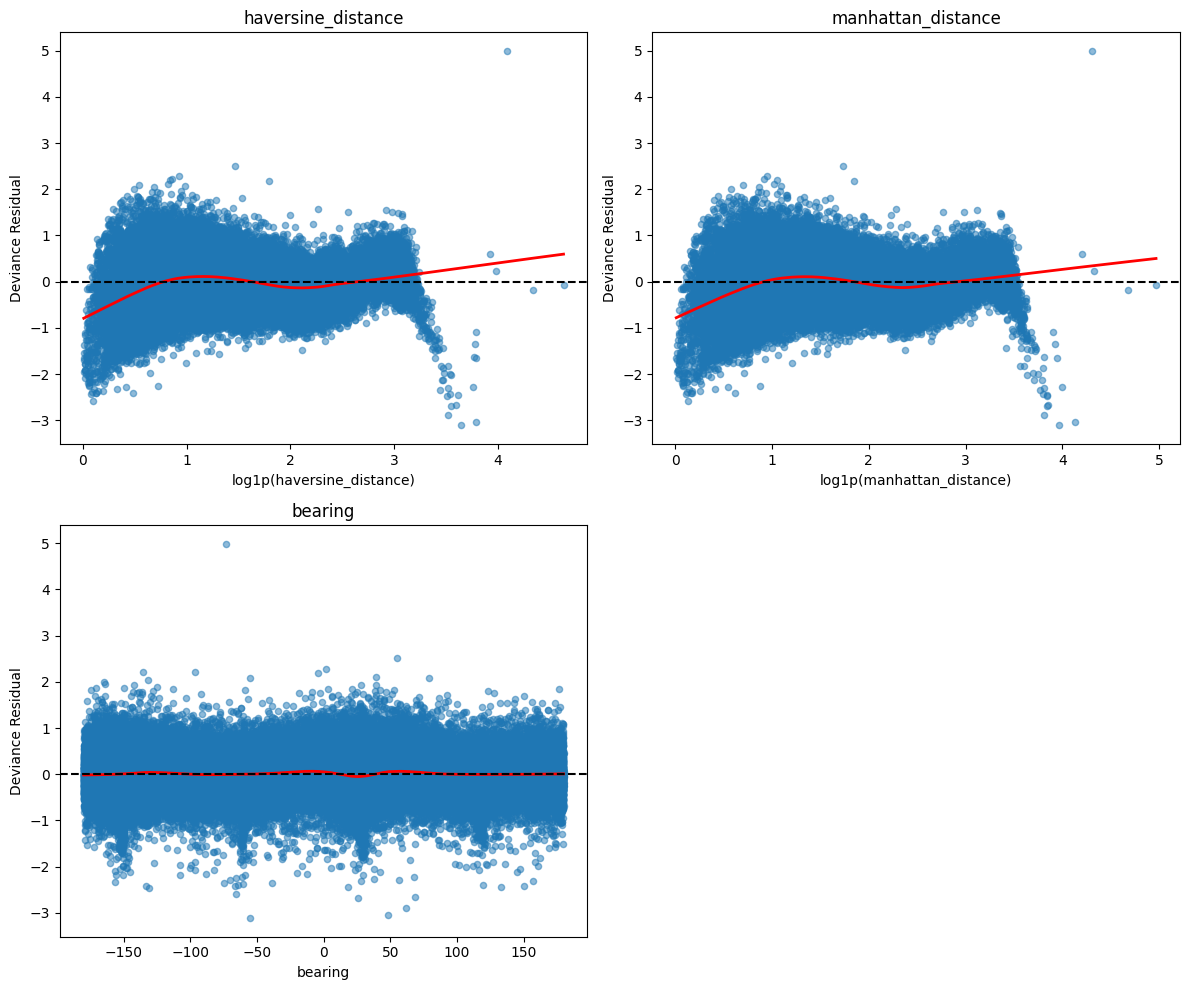

In [28]:
per_predictor_diagnostics_gam(
    final_model_pygam,
    preprocessor_pygam,
    X_train_df=results_pygam["X_train_df"],
    y_train=results_pygam["y_train"],
    X_train=results_pygam["X_train"],
    fit_idx=results_pygam["final_fit_idx"],
    model_type='pygam',
    log_features=["haversine_distance", "manhattan_distance"],
)

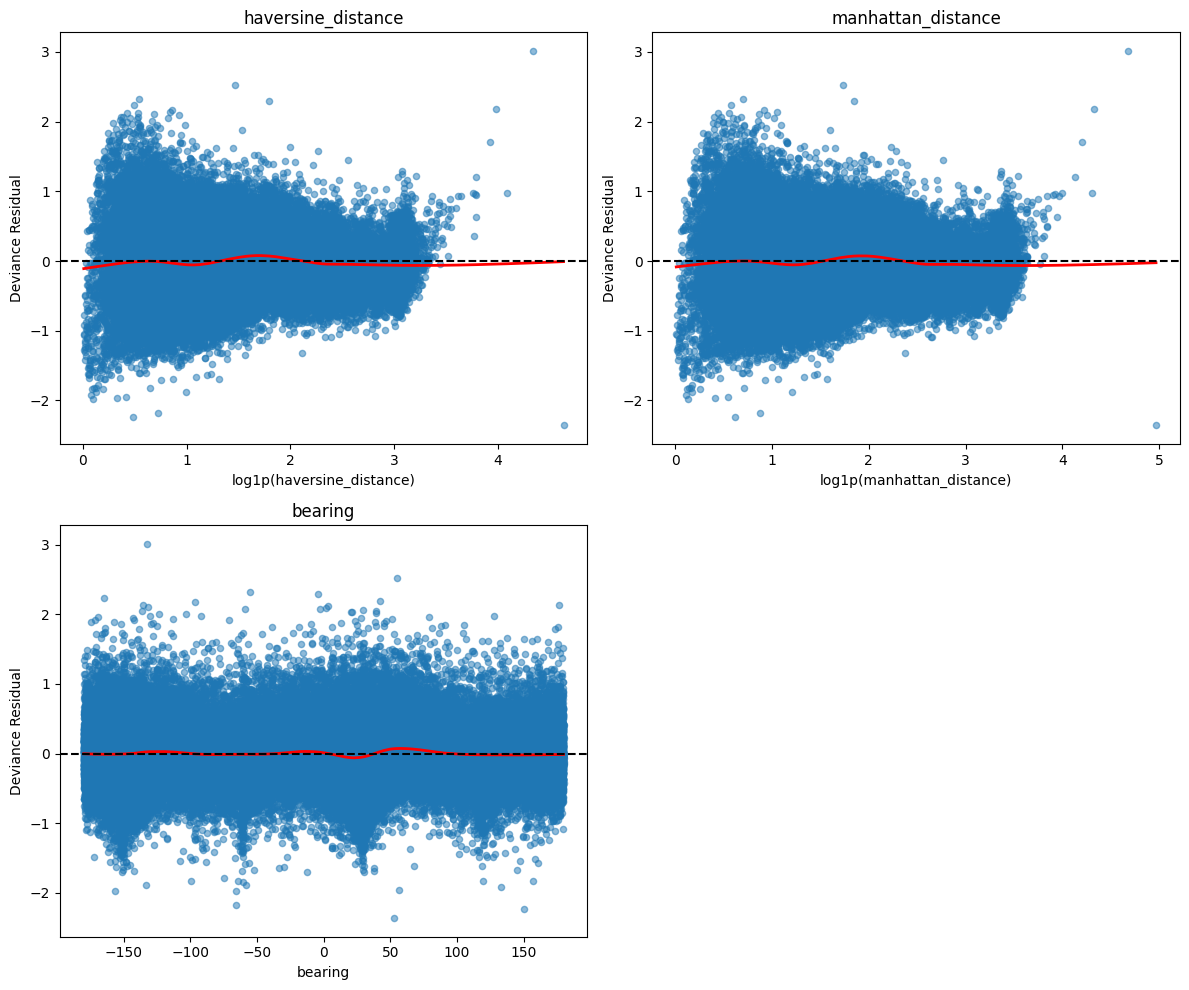

In [29]:
per_predictor_diagnostics_gam(
    final_model_glmgam,
    preprocessor_glmgam,
    X_train_df=results_glmgam["X_train_df"],
    y_train=results_glmgam["y_train"],
    X_train=results_glmgam["X_train"],
    fit_idx=results_glmgam["final_fit_idx"],
    model_type='statsmodels-glmgam',
    log_features=["haversine_distance", "manhattan_distance"],
)

KeyboardInterrupt: 

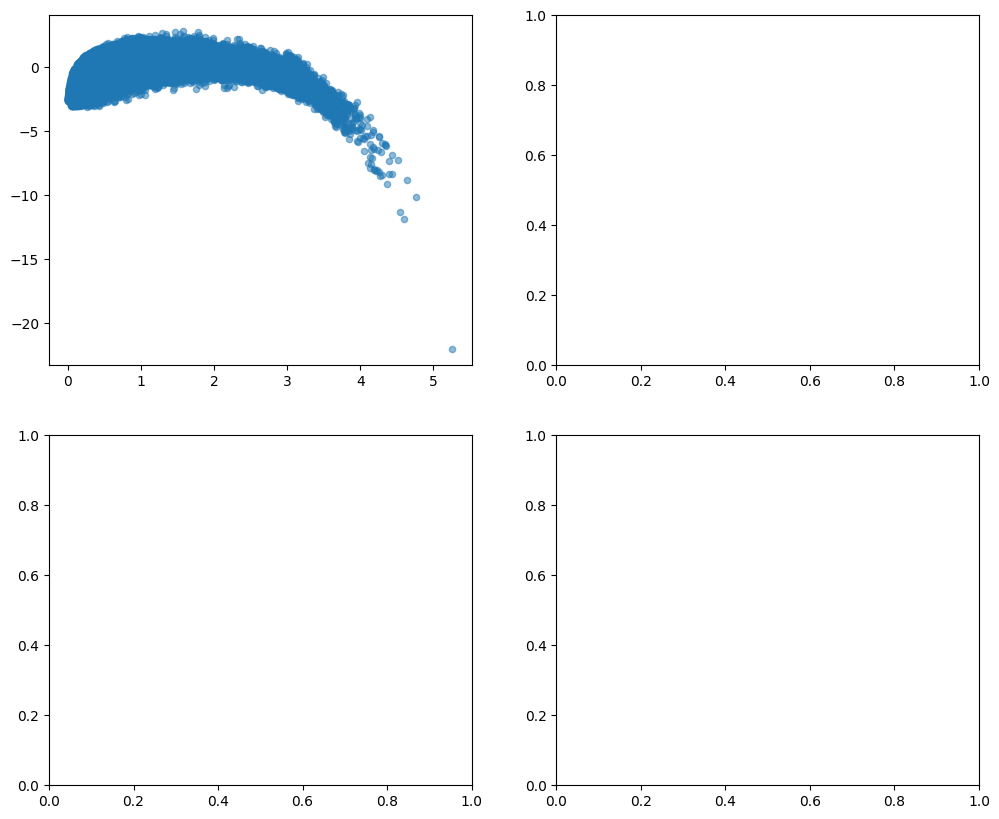

In [ ]:
# per_predictor_diagnostics_gam(
#     final_model_glm,
#     preprocessor_glm,
#     X_train_df=results_glm["X_train_df"],
#     y_train=results_glm["y_train"],
#     X_train=results_glm["X_train"],
#     # fit_idx=results_glm["final_fit_idx"],
#     model_type='statsmodels-glm',
#     log_features=["haversine_distance", "manhattan_distance"],
# )

In [ ]:
results_ols_reg = run_cv_and_fit(
       df_train.drop(columns=['trip_duration']),
       framework='statsmodels-ols-regularized',
       reg_alpha_grid=[0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
       reg_L1_wt_grid=[0.0, 0.1, 0.25, 0.5],  
   )


In [ ]:
final_model_glm_ols_reg = results_ols_reg["final_model"]
preprocessor_glm_ols_reg = results_ols_reg["preprocessor"]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, root_mean_squared_error,
    median_absolute_error, r2_score
)


def evaluate_regularized_model(model, X, y, preprocessor, feature_names=None, top_n_coefs=25):
    
    import statsmodels.api as sm

    X_sm = sm.add_constant(X, has_constant='add')
    y_pred = model.predict(X_sm)
    resid = y - y_pred

    n = len(y)
    p = X_sm.shape[1]  # includes intercept

    # --- Core error metrics ---
    metrics = {
        "n_obs": n,
        "n_params": p,
        "MSE": mean_squared_error(y, y_pred),
        "RMSE": root_mean_squared_error(y, y_pred),
        "MAE": mean_absolute_error(y, y_pred),
        "MedAE": median_absolute_error(y, y_pred),
        "R2": r2_score(y, y_pred),
    }

    # Adjusted R^2 (manual, since not provided)
    r2 = metrics["R2"]
    if n - p - 1 > 0:
        metrics["Adj_R2"] = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    else:
        metrics["Adj_R2"] = np.nan

    
    resid_var = np.var(resid, ddof=0)
    if resid_var > 0:
        pseudo_ll = -n / 2 * (np.log(2 * np.pi * resid_var) + 1)
        metrics["Pseudo_LogLikelihood"] = pseudo_ll
        metrics["Pseudo_AIC"] = -2 * pseudo_ll + 2 * p
        metrics["Pseudo_BIC"] = -2 * pseudo_ll + p * np.log(n)
    else:
        metrics["Pseudo_LogLikelihood"] = np.nan
        metrics["Pseudo_AIC"] = np.nan
        metrics["Pseudo_BIC"] = np.nan

    print("=== Fit Metrics (manual, since fit_regularized() has no .summary()) ===")
    for k, v in metrics.items():
        print(f"{k:>22}: {v:,.4f}" if isinstance(v, (float, np.floating)) else f"{k:>22}: {v}")

    # --- Coefficients table ---
    if feature_names is None:
        try:
            feature_names = preprocessor.get_feature_names_out().tolist()
        except Exception:
            feature_names = [f"x{i}" for i in range(X.shape[1])]

    coef_names = ["const"] + feature_names
    coefs = pd.Series(model.params, index=coef_names, name="coefficient")

    n_nonzero = (coefs.drop("const") != 0).sum()
    n_total = len(coefs) - 1
    print(f"\n=== Sparsity ===")
    print(f"Non-zero coefficients (excl. intercept): {n_nonzero} / {n_total} "
          f"({100 * n_nonzero / n_total:.1f}% retained)")

    print(f"\n=== Top {top_n_coefs} coefficients by |magnitude| ===")
    top_coefs = coefs.drop("const").reindex(
        coefs.drop("const").abs().sort_values(ascending=False).index
    ).head(top_n_coefs)
    print(top_coefs)

    print(f"\n=== Coefficients shrunk to exactly zero (first 20) ===")
    zeroed = coefs.drop("const")[coefs.drop("const") == 0]
    print(zeroed.head(20).index.tolist(), f"... ({len(zeroed)} total)" if len(zeroed) > 20 else "")

    return {
        "metrics": metrics,
        "coefs": coefs,
        "y_pred": y_pred,
        "resid": resid,
        "n_nonzero": n_nonzero,
        "n_total": n_total,
    }

In [ ]:
X_train = results_ols_reg["X_train"]
y_train = results_ols_reg["y_train"]

eval_results = evaluate_regularized_model(
    final_model_glm_ols_reg,
    X_train,
    y_train,
    preprocessor_glm_ols_reg,
)

coefs = eval_results["coefs"]
y_pred = eval_results["y_pred"]
resid = eval_results["resid"]

In [ ]:
import matplotlib.pyplot as plt

grid_scores = results_ols_reg["reg_grid_scores"]

fig, ax = plt.subplots(figsize=(8, 5))

for l1, group in grid_scores.groupby("L1_wt"):
    group = group.sort_values("alpha")
    ax.plot(group["alpha"], group["mean_rmse"], marker="o", label=f"L1_wt={l1}")

ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Mean CV RMSE (log-target scale)")
ax.set_title("Regularization grid search: RMSE vs. alpha")
ax.legend(title="L1_wt")
plt.tight_layout()
plt.show()